## 1. Setup: GPU, Kaggle e dipendenze

In [2]:
# Verifica che la GPU sia attiva
import torch
print(f"CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  GPU non trovata! Vai su Runtime → Cambia tipo di runtime → T4 GPU")

CUDA disponibile: True
GPU: Tesla T4


In [3]:
 # Installa kagglehub
!pip install kagglehub -q #quietly

In [4]:
# Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)

100%|██████████| 1.07G/1.07G [00:29<00:00, 39.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12


In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Riproducibilità
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Download e analisi del Dataset

In [6]:
import kagglehub

dataset_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print(f"Dataset scaricato in: {dataset_path}")

# Trova la cartella con le classi
data_root = None
for root, dirs, files in os.walk(dataset_path):
    if 'glass' in dirs:
        data_root = root
        break

assert data_root is not None, "Struttura dataset non trovata!"
classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
print(f"Classi ({len(classes)}): {classes}")

Dataset scaricato in: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12
Classi (10): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


Totale immagini: 12259
  battery        :  756
  biological     :  699
  cardboard      : 1411
  clothes        : 1892
  glass          : 1736
  metal          :  930
  paper          : 1336
  plastic        : 1597
  shoes          : 1449
  trash          :  453


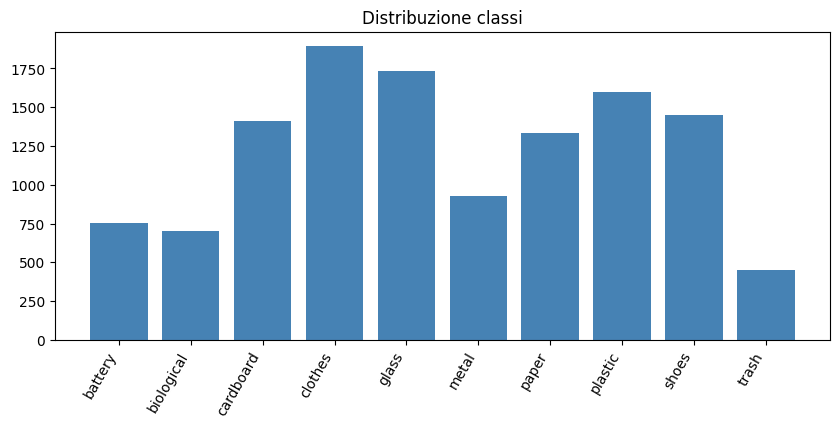

In [7]:
# Distribuzione delle classi
class_counts = {}
for cls in classes:
    imgs = [f for f in os.listdir(os.path.join(data_root, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)

total = sum(class_counts.values())
print(f"Totale immagini: {total}")
for cls, cnt in class_counts.items():
    print(f"  {cls:15s}: {cnt:4d}")

plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("Distribuzione classi")
plt.xticks(rotation=60, ha='right')
plt.show()

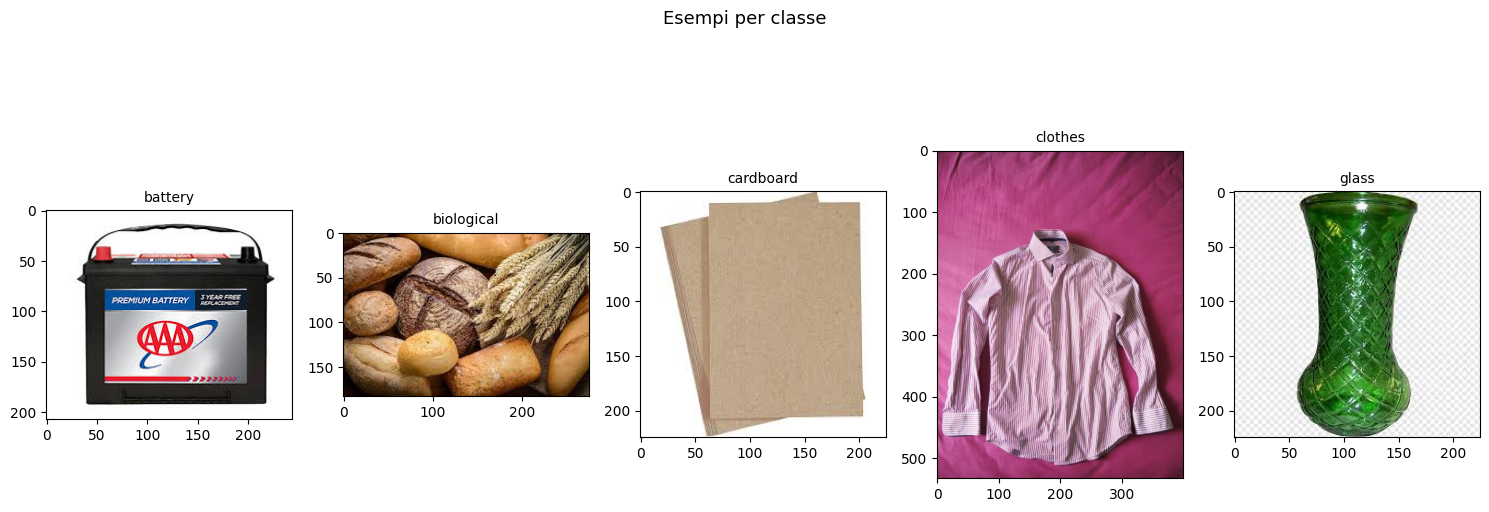

In [8]:
# Esempio di immagini per ogni classe
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i, cls in enumerate(classes[:5]):
    cls_path = os.path.join(data_root, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img = plt.imread(os.path.join(cls_path, random.choice(imgs)))
    axes.flatten()[i].imshow(img)
    axes.flatten()[i].set_title(cls, fontsize=10)
    axes.flatten()[i].axis('on')
plt.suptitle("Esempi per classe", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocessing, Augmentation e Split

**Data Augmentation** (solo su training set): flip, rotazione, jitter di colore, random crop.  
Aumenta artificialmente la variabilità → meno overfitting, modello più robusto.

**Split 70/15/15 stratificato**: ogni split mantiene la stessa proporzione di classi.  
Il test set viene toccato **solo alla fine**, dopo la model selection.

In [9]:
IMG_SIZE = 224 #resnet18
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([ #trasformazioni in sequenza esatta
    transforms.Resize((IMG_SIZE, IMG_SIZE)),#resize con input resnet
    transforms.RandomHorizontalFlip(p=0.5),#rotazione completa orizzontale casuale
    transforms.RandomRotation(degrees=15), #rotazione 15 gradi (un rifiuto ruotato è comunque un rifiuto)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05), #variazioni casuali di luminosità e contrasto
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),# introduco zoom casuale
    transforms.ToTensor(), #trasmormo in tensore come vuole resnet
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD), #bilancio i gradienti con la normalizzazione attorto alla media (0)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])#nel validation evito di mettere la stessa randomicità

# Split stratificato 70 / 15 / 15
full_dataset = datasets.ImageFolder(root=data_root)#leggo sottocartelle e assegno indice
all_indices  = list(range(len(full_dataset))) #conto tutte le immagini, genero una sequenza e creo una lista
all_labels   = full_dataset.targets   #preparo label numerica di tutte le immagini [0,..,0(pos.756),1..,1(pos.1455),etc.]

trainval_idx, test_idx = train_test_split( #train_test_split funzione di sklearn con cui divido la lista
    all_indices, test_size=0.15, stratify=all_labels, random_state=SEED) #metto il 15% del DS nel test set

trainval_labels = [all_labels[i] for i in trainval_idx]
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.15/0.85, stratify=trainval_labels, random_state=SEED) # qui splitto il traning e validation set

print(f"Train:      {len(train_idx):5d} ({len(train_idx)/len(all_indices)*100:.1f}%)")
print(f"Validation: {len(val_idx):5d} ({len(val_idx)/len(all_indices)*100:.1f}%)")
print(f"Test:       {len(test_idx):5d} ({len(test_idx)/len(all_indices)*100:.1f}%)")

BATCH_SIZE  = 64   # su GPU usare batch più grandi, 32 su CPU
NUM_WORKERS = 2
NUM_CLASSES = len(full_dataset.classes) #ovviamente 10

train_dataset = Subset(datasets.ImageFolder(data_root, transform=train_transform), train_idx)
val_dataset   = Subset(datasets.ImageFolder(data_root, transform=eval_transform),  val_idx)
test_dataset  = Subset(datasets.ImageFolder(data_root, transform=eval_transform),  test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nClassi: {full_dataset.classes}")

Train:       8581 (70.0%)
Validation:  1839 (15.0%)
Test:        1839 (15.0%)

Classi: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


## 4. Modello: ResNet-18 con Transfer Learning

Uso ResNet-18 pre-addestrata su ImageNet


In [10]:
def build_model(num_classes, dropout_rate=0.5, freeze_backbone=True, finetune_layer4=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Fine-tuning: risblocco SOLO l'ultimo blocco del backbone.
    # Va fatto DOPO il freeze, altrimenti il loop sopra lo ricongelerebbe.
    if finetune_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features  # 512 per ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate / 2),
        nn.Linear(256, num_classes)
        # Niente Softmax: CrossEntropyLoss lo include internamente
    )
    return model

# Test rapido — confronta i due scenari
for ft in [False, True]:
    m = build_model(NUM_CLASSES, finetune_layer4=ft)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"finetune_layer4={ft!s:5} → addestrabili: {trainable:,} ({trainable/total*100:.1f}%)")
    del m

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


finetune_layer4=False → addestrabili: 133,898 (1.2%)
finetune_layer4=True  → addestrabili: 8,527,626 (75.4%)


## 5. Training Loop

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += labels.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        loss_sum += loss.item() * images.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += labels.size(0)
    return loss_sum / total, correct / total


def train_model(model, train_loader, val_loader, config, device, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_loss, best_val_acc = float('inf'), 0.0
    patience_counter = 0
    best_state = None

    for epoch in range(config['epochs']):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)

        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)

        if verbose:
            print(f"Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"Train Loss: {tl:.4f} Acc: {ta:.3f} | "
                  f"Val Loss: {vl:.4f} Acc: {va:.3f}")

        if vl < best_val_loss:
            best_val_loss = vl
            best_val_acc  = va
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                if verbose:
                    print(f"  → Early stopping all'epoca {epoch+1}")
                break

    model.load_state_dict(best_state)
    return history, best_val_acc

print("Training loop pronto.")

Training loop pronto.


## 6. Model Selection — Grid Search

Testiamo diverse combinazioni di iperparametri valutando la **validation accuracy**.  
La scelta finale avviene **senza mai guardare il test set**.

In [12]:
param_grid = [
    {'lr': 1e-3, 'weight_decay': 1e-4, 'dropout_rate': 0.3}
]

BASE_CONFIG = {'epochs': 24, 'patience': 4}

results = []

for i, params in enumerate(param_grid):
    print(f"\n{'='*60}")
    print(f"Config {i+1}/{len(param_grid)}: {params}")
    print('='*60)

    m = build_model(NUM_CLASSES, dropout_rate=params['dropout_rate']).to(DEVICE)
    cfg = {**BASE_CONFIG, 'lr': params['lr'], 'weight_decay': params['weight_decay']}
    history, best_val_acc = train_model(m, train_loader, val_loader, cfg, DEVICE)

    results.append({'params': params, 'best_val_acc': best_val_acc,
                    'history': history, 'model': m})
    print(f"→ Best Val Accuracy: {best_val_acc:.4f}")

# Migliore configurazione
best_result = max(results, key=lambda x: x['best_val_acc'])
best_params = best_result['params']
best_model  = best_result['model'].to(DEVICE)

print(f"\n{'='*60}")
print(f"MIGLIORI IPERPARAMETRI: {best_params}")
print(f"Best Val Accuracy: {best_result['best_val_acc']:.4f}")
print('='*60)

print("\nRiepilogo model selection (ordinato):")
for r in sorted(results, key=lambda x: x['best_val_acc'], reverse=True):
    print(f"  Val Acc: {r['best_val_acc']:.4f} | {r['params']}")


Config 1/1: {'lr': 0.001, 'weight_decay': 0.0001, 'dropout_rate': 0.3}
Epoch   1/24 | Train Loss: 0.9626 Acc: 0.688 | Val Loss: 0.4690 Acc: 0.848
Epoch   2/24 | Train Loss: 0.6666 Acc: 0.778 | Val Loss: 0.4542 Acc: 0.856
Epoch   3/24 | Train Loss: 0.6177 Acc: 0.793 | Val Loss: 0.4269 Acc: 0.860
Epoch   4/24 | Train Loss: 0.6014 Acc: 0.791 | Val Loss: 0.3989 Acc: 0.869
Epoch   5/24 | Train Loss: 0.5758 Acc: 0.800 | Val Loss: 0.3935 Acc: 0.869
Epoch   6/24 | Train Loss: 0.5612 Acc: 0.808 | Val Loss: 0.3677 Acc: 0.879
Epoch   7/24 | Train Loss: 0.5434 Acc: 0.815 | Val Loss: 0.3708 Acc: 0.884
Epoch   8/24 | Train Loss: 0.5168 Acc: 0.822 | Val Loss: 0.3960 Acc: 0.869
Epoch   9/24 | Train Loss: 0.5118 Acc: 0.827 | Val Loss: 0.3461 Acc: 0.889
Epoch  10/24 | Train Loss: 0.5078 Acc: 0.824 | Val Loss: 0.3350 Acc: 0.891
Epoch  11/24 | Train Loss: 0.4979 Acc: 0.830 | Val Loss: 0.3463 Acc: 0.891
Epoch  12/24 | Train Loss: 0.4896 Acc: 0.831 | Val Loss: 0.3500 Acc: 0.881
Epoch  13/24 | Train Loss: 0

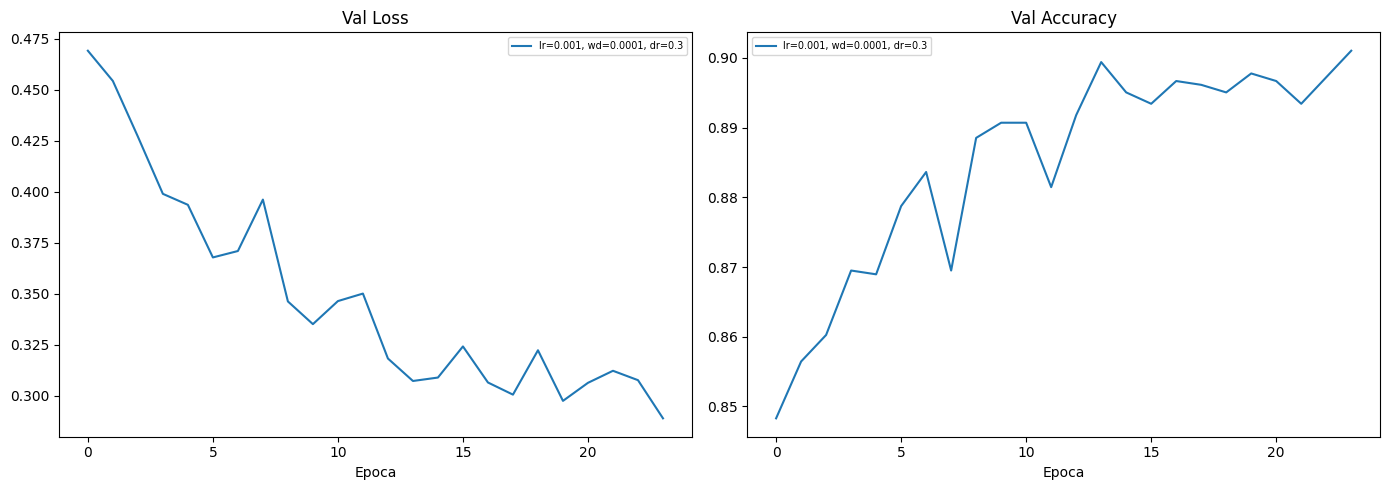

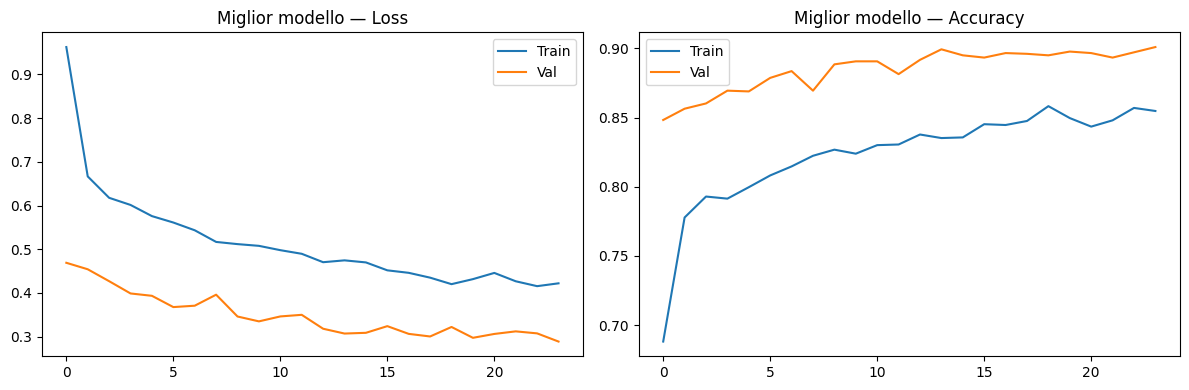

In [13]:
# Learning curves — confronto configurazioni
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    lbl = f"lr={r['params']['lr']}, wd={r['params']['weight_decay']}, dr={r['params']['dropout_rate']}"
    axes[0].plot(r['history']['val_loss'], label=lbl)
    axes[1].plot(r['history']['val_acc'],  label=lbl)
axes[0].set_title("Val Loss");     axes[0].set_xlabel("Epoca"); axes[0].legend(fontsize=7)
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoca"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

# Learning curves — miglior modello: train vs val
hist = best_result['history']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['train_loss'], label='Train'); axes[0].plot(hist['val_loss'], label='Val')
axes[0].set_title("Miglior modello — Loss"); axes[0].legend()
axes[1].plot(hist['train_acc'], label='Train'); axes[1].plot(hist['val_acc'], label='Val')
axes[1].set_title("Miglior modello — Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Valutazione Finale sul Test Set

Solo ora valutiamo sul test set. Questa stima è **non distorta** perché il test set non ha mai influenzato nessuna scelta (architettura, iperparametri, early stopping).

In [14]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, DEVICE)

print(f"{'='*50}")
print(f"  RISULTATI FINALI — TEST SET")
print(f"{'='*50}")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*50}")
print(f"\n  Iperparametri scelti:")
for k, v in best_params.items():
    print(f"    {k}: {v}")

  RISULTATI FINALI — TEST SET
  Test Loss:     0.2886
  Test Accuracy: 0.9027  (90.27%)

  Iperparametri scelti:
    lr: 0.001
    weight_decay: 0.0001
    dropout_rate: 0.3


In [15]:
# Raccogliamo predizioni e label vere
best_model.eval()
all_preds, all_labels_list = [], []
with torch.no_grad():
    for images, labels in test_loader:
        out = best_model(images.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels_list.extend(labels.numpy())

class_names = full_dataset.classes

# Classification report
print("Classification Report:")
print(classification_report(all_labels_list, all_preds, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

     battery       0.92      0.96      0.94       113
  biological       0.97      0.95      0.96       105
   cardboard       0.89      0.91      0.90       212
     clothes       0.96      0.99      0.98       284
       glass       0.84      0.93      0.88       260
       metal       0.81      0.85      0.83       140
       paper       0.89      0.84      0.86       200
     plastic       0.89      0.77      0.82       240
       shoes       0.96      0.99      0.97       217
       trash       0.94      0.72      0.82        68

    accuracy                           0.90      1839
   macro avg       0.91      0.89      0.90      1839
weighted avg       0.90      0.90      0.90      1839



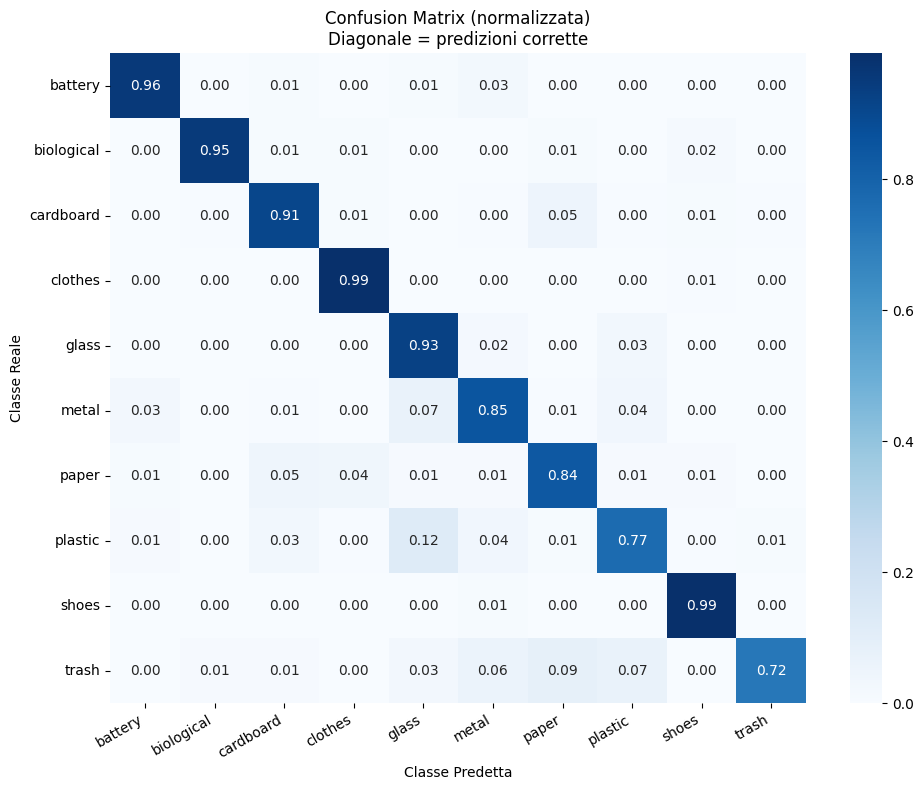

In [16]:
# Confusion Matrix normalizzata
cm = confusion_matrix(all_labels_list, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix (normalizzata)\nDiagonale = predizioni corrette")
plt.ylabel("Classe Reale")
plt.xlabel("Classe Predetta")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Salvataggio modello su Google Drive (opzionale ma consigliato!)
# Se non usi Drive, il modello viene perso quando la sessione Colab scade.

# Opzione A: scarica direttamente
torch.save({
    'model_state_dict': best_model.state_dict(),
    'best_params': best_params,
    'test_accuracy': test_acc,
    'class_names': class_names,
}, 'best_garbage_classifier.pth')

from google.colab import files
files.download('best_garbage_classifier.pth')
print("Modello scaricato!")

# Opzione B: salva su Google Drive (decommentare le righe sotto)
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save({...}, '/content/drive/MyDrive/best_garbage_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modello scaricato!


## 8. Conclusioni

| Scelta | Valore | Motivazione |
|--------|--------|-------------|
| Architettura | ResNet-18 (Transfer Learning) | Performance/velocità; pesi ImageNet |
| Ottimizzatore | Adam | Adattivo, buona convergenza |
| Loss | CrossEntropyLoss | Standard classificazione multiclasse |
| Regularization | Dropout + Weight Decay | Previene overfitting |
| Augmentation | Flip, Rotation, ColorJitter, RandomCrop | Variabilità → robustezza |
| LR Scheduler | ReduceLROnPlateau | Adatta LR alla convergenza |
| Early Stopping | patience=6 | Evita overfitting, risparmia tempo |
| Model Selection | Grid Search su Val Set | Scelta HP senza toccare il test set |
| Split | 70/15/15 stratificato | Distribuzione bilanciata in ogni split |

### Possibili miglioramenti
- Fine-tuning completo del backbone (sbloccare tutti i layer dopo le prime epoche)
- Architetture più potenti: EfficientNet-B0, ResNet-50
- Class weights nella loss per gestire lo sbilanciamento
- MixUp / CutMix augmentation